In [ ]:
!pip install torch_geometric ogb -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x

In [3]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from torch_geometric.transforms import ToUndirected, AddSelfLoops, Compose
import time

if not hasattr(torch.load, '_patched'):
    _original_load = torch.load

    def _patched_load(f, **kwargs):
        kwargs["weights_only"] = False
        return _original_load(f, **kwargs)

    _patched_load._patched = True
    torch.load = _patched_load

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    transform=Compose([ToUndirected(), AddSelfLoops()])
)

split_idx = dataset.get_idx_split()
data = dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_idx = split_idx['train'].to(device)
val_idx   = split_idx['valid'].to(device)
test_idx  = split_idx['test'].to(device)

print(data)
print(f"Device: {device}")
print(f"Num classes: {dataset.num_classes}")

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:02<00:00, 31.90it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 9868.95it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 355.69it/s]

Saving...



Done!


Data(num_nodes=169343, edge_index=[2, 2484941], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Device: cuda
Num classes: 40


In [4]:
evaluator = Evaluator(name='ogbn-arxiv')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[train_idx], data.y[train_idx].squeeze())

    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1, keepdim=True)

    results = {}
    for split, idx in [('train', train_idx), ('valid', val_idx), ('test', test_idx)]:
        acc = evaluator.eval({
            'y_true': data.y[idx],
            'y_pred': pred[idx]
        })['acc']
        results[split] = acc
    return results

In [5]:
model = GCN(
    in_channels=dataset.num_features,   # 128
    hidden_channels=256,
    out_channels=dataset.num_classes,   # 40
    num_layers=3,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (convs): ModuleList(
    (0): GCNConv(128, 256)
    (1): GCNConv(256, 256)
    (2): GCNConv(256, 40)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
Num parameters: 110,120


In [6]:
history = {
    'epoch': [],
    'loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

In [7]:
NUM_EPOCHS = 500
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t
    scheduler.step()

    if epoch % 10 == 0:
        results = evaluate(model)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train: {results['train']:.4f} | "
              f"Val: {results['valid']:.4f} | "
              f"Test: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")
        
        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['train_acc'].append(results['train'])
        history['val_acc'].append(results['valid'])
        history['test_acc'].append(results['test'])

        if results['valid'] > best_val_acc:
            best_val_acc  = results['valid']
            best_test_acc = results['test']
            torch.save(model.state_dict(), 'best_gcn.pt')

print(f"\nBest Val Acc:  {best_val_acc:.4f}")
print(f"Best Test Acc: {best_test_acc:.4f}")

Epoch 010 | Loss: 1.3161 | Train: 0.4125 | Val: 0.2924 | Test: 0.2738 | Time: 0.35s
Epoch 020 | Loss: 1.1333 | Train: 0.5199 | Val: 0.5009 | Test: 0.5426 | Time: 0.35s
Epoch 030 | Loss: 1.0445 | Train: 0.6303 | Val: 0.6335 | Test: 0.6491 | Time: 0.35s
Epoch 040 | Loss: 0.9912 | Train: 0.6833 | Val: 0.6775 | Test: 0.6838 | Time: 0.35s
Epoch 050 | Loss: 0.9590 | Train: 0.6915 | Val: 0.6840 | Test: 0.6865 | Time: 0.35s
Epoch 060 | Loss: 0.9387 | Train: 0.7152 | Val: 0.7045 | Test: 0.6992 | Time: 0.35s
Epoch 070 | Loss: 0.9226 | Train: 0.7207 | Val: 0.7065 | Test: 0.7005 | Time: 0.35s
Epoch 080 | Loss: 0.9066 | Train: 0.7275 | Val: 0.7123 | Test: 0.7072 | Time: 0.35s
Epoch 090 | Loss: 0.8892 | Train: 0.7306 | Val: 0.7126 | Test: 0.7058 | Time: 0.35s
Epoch 100 | Loss: 0.8711 | Train: 0.7328 | Val: 0.7124 | Test: 0.7053 | Time: 0.35s
Epoch 110 | Loss: 0.8620 | Train: 0.7423 | Val: 0.7184 | Test: 0.7114 | Time: 0.35s
Epoch 120 | Loss: 0.8574 | Train: 0.7439 | Val: 0.7161 | Test: 0.7020 | Time

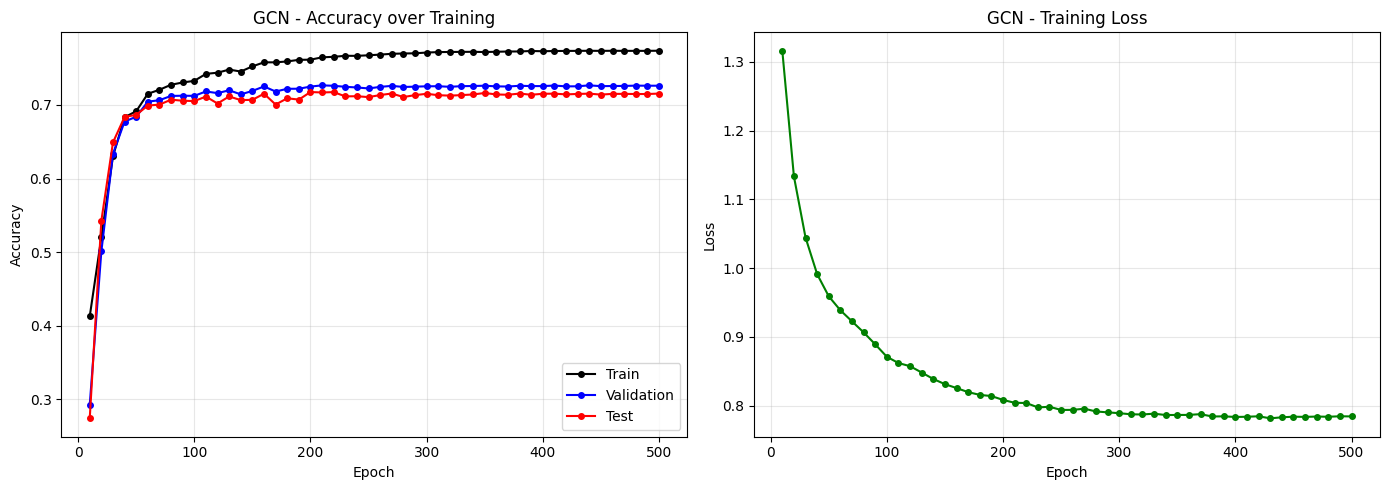

Best Val Acc:  0.7267
Best Test Acc: 0.717


In [8]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 501, 10))

train_accs = [
    0.4125, 0.5199, 0.6303, 0.6833, 0.6915, 0.7152, 0.7207, 0.7275, 0.7306, 0.7328,
    0.7423, 0.7439, 0.7481, 0.7455, 0.7525, 0.7580, 0.7580, 0.7592, 0.7614, 0.7616,
    0.7648, 0.7655, 0.7669, 0.7668, 0.7676, 0.7685, 0.7696, 0.7700, 0.7703, 0.7713,
    0.7719, 0.7721, 0.7722, 0.7723, 0.7720, 0.7724, 0.7727, 0.7728, 0.7734, 0.7731,
    0.7734, 0.7735, 0.7736, 0.7737, 0.7736, 0.7737, 0.7736, 0.7736, 0.7736, 0.7738
]

val_accs = [
    0.2924, 0.5009, 0.6335, 0.6775, 0.6840, 0.7045, 0.7065, 0.7123, 0.7126, 0.7124,
    0.7184, 0.7161, 0.7200, 0.7144, 0.7191, 0.7252, 0.7183, 0.7220, 0.7221, 0.7250,
    0.7267, 0.7261, 0.7247, 0.7238, 0.7225, 0.7246, 0.7260, 0.7245, 0.7249, 0.7254,
    0.7255, 0.7247, 0.7256, 0.7258, 0.7262, 0.7253, 0.7251, 0.7261, 0.7257, 0.7257,
    0.7264, 0.7253, 0.7254, 0.7267, 0.7256, 0.7258, 0.7259, 0.7263, 0.7262, 0.7262
]

test_accs = [
    0.2738, 0.5426, 0.6491, 0.6838, 0.6865, 0.6992, 0.7005, 0.7072, 0.7058, 0.7053,
    0.7114, 0.7020, 0.7116, 0.7066, 0.7070, 0.7153, 0.7006, 0.7091, 0.7073, 0.7176,
    0.7170, 0.7175, 0.7117, 0.7119, 0.7107, 0.7135, 0.7156, 0.7108, 0.7134, 0.7152,
    0.7133, 0.7127, 0.7134, 0.7143, 0.7163, 0.7143, 0.7139, 0.7155, 0.7139, 0.7152,
    0.7154, 0.7144, 0.7150, 0.7154, 0.7141, 0.7151, 0.7151, 0.7149, 0.7149, 0.7155
]

losses = [
    1.3161, 1.1333, 1.0445, 0.9912, 0.9590, 0.9387, 0.9226, 0.9066, 0.8892, 0.8711,
    0.8620, 0.8574, 0.8482, 0.8388, 0.8313, 0.8256, 0.8197, 0.8157, 0.8140, 0.8084,
    0.8042, 0.8039, 0.7975, 0.7984, 0.7938, 0.7939, 0.7956, 0.7916, 0.7903, 0.7891,
    0.7875, 0.7872, 0.7884, 0.7864, 0.7865, 0.7866, 0.7877, 0.7843, 0.7845, 0.7836,
    0.7839, 0.7846, 0.7816, 0.7831, 0.7840, 0.7837, 0.7842, 0.7839, 0.7846, 0.7844
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, train_accs, 'k-o', label='Train', markersize=4)
ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test', markersize=4)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GCN - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GCN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

print("Best Val Acc: ", max(val_accs))
print("Best Test Acc:", test_accs[val_accs.index(max(val_accs))])

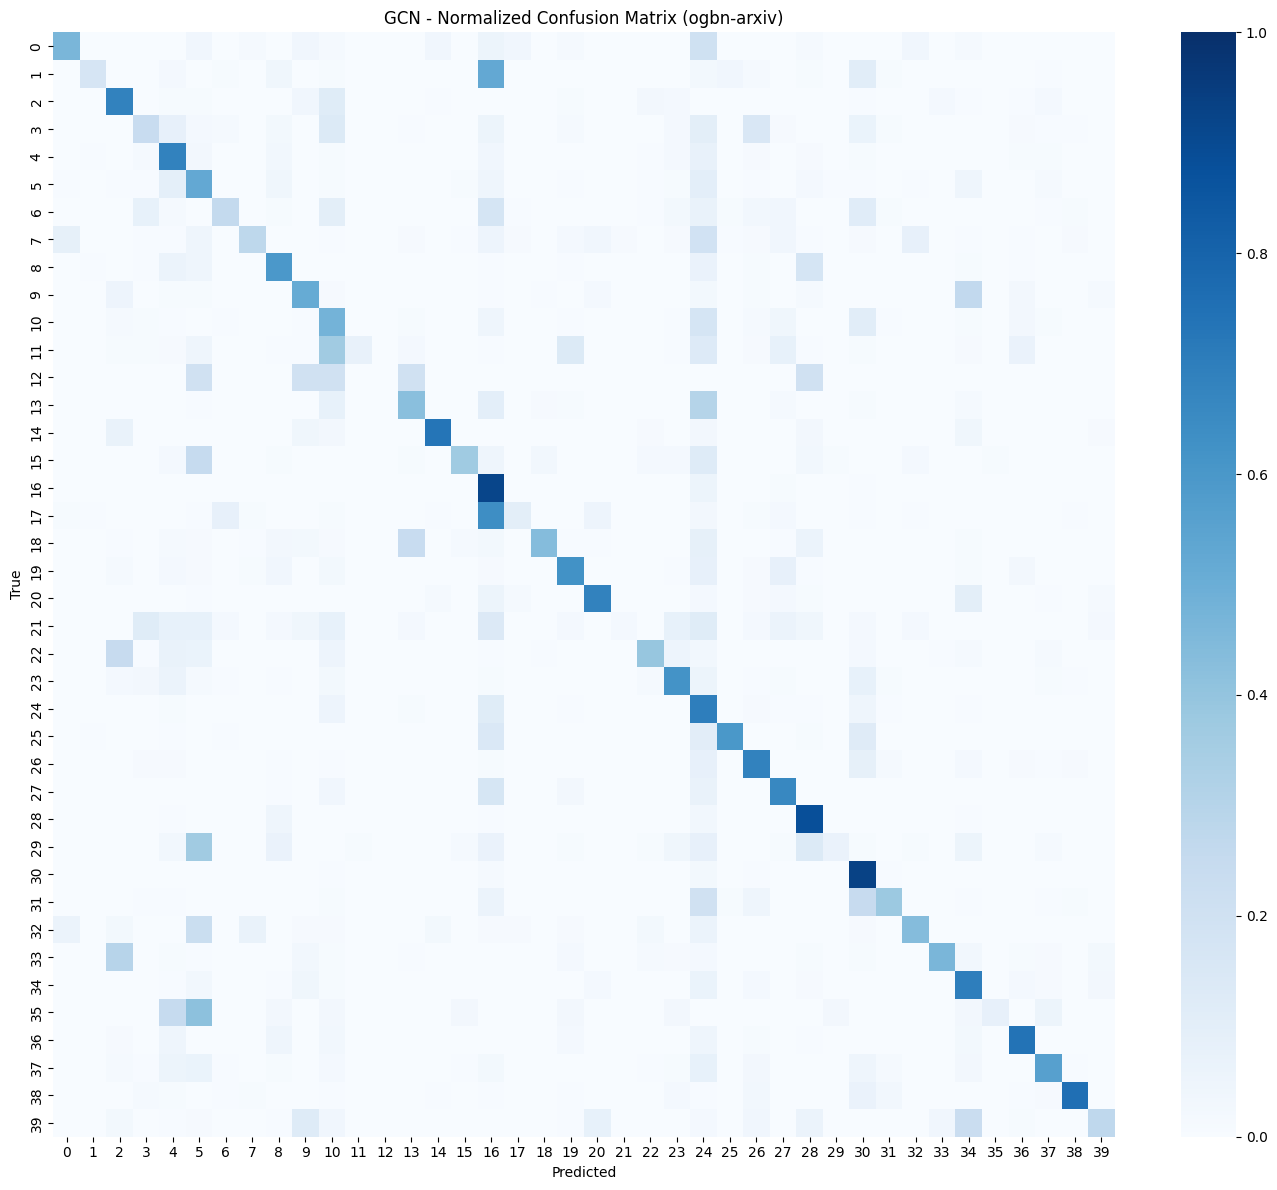

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import os

if os.path.exists('/kaggle/working/best_gcn.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gcn.pt', map_location=device))
elif os.path.exists('best_gcn.pt'):
    model.load_state_dict(torch.load('best_gcn.pt', map_location=device))

@torch.no_grad()
def get_test_predictions(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=-1)

    test_preds = pred[test_idx].detach().cpu()
    test_labels = data.y[test_idx].squeeze().detach().cpu()
    return test_labels, test_preds

test_labels, test_preds = get_test_predictions(model)

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=list(range(dataset.num_classes)))
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)  # protects against empty classes

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GCN - Normalized Confusion Matrix (ogbn-arxiv)')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()


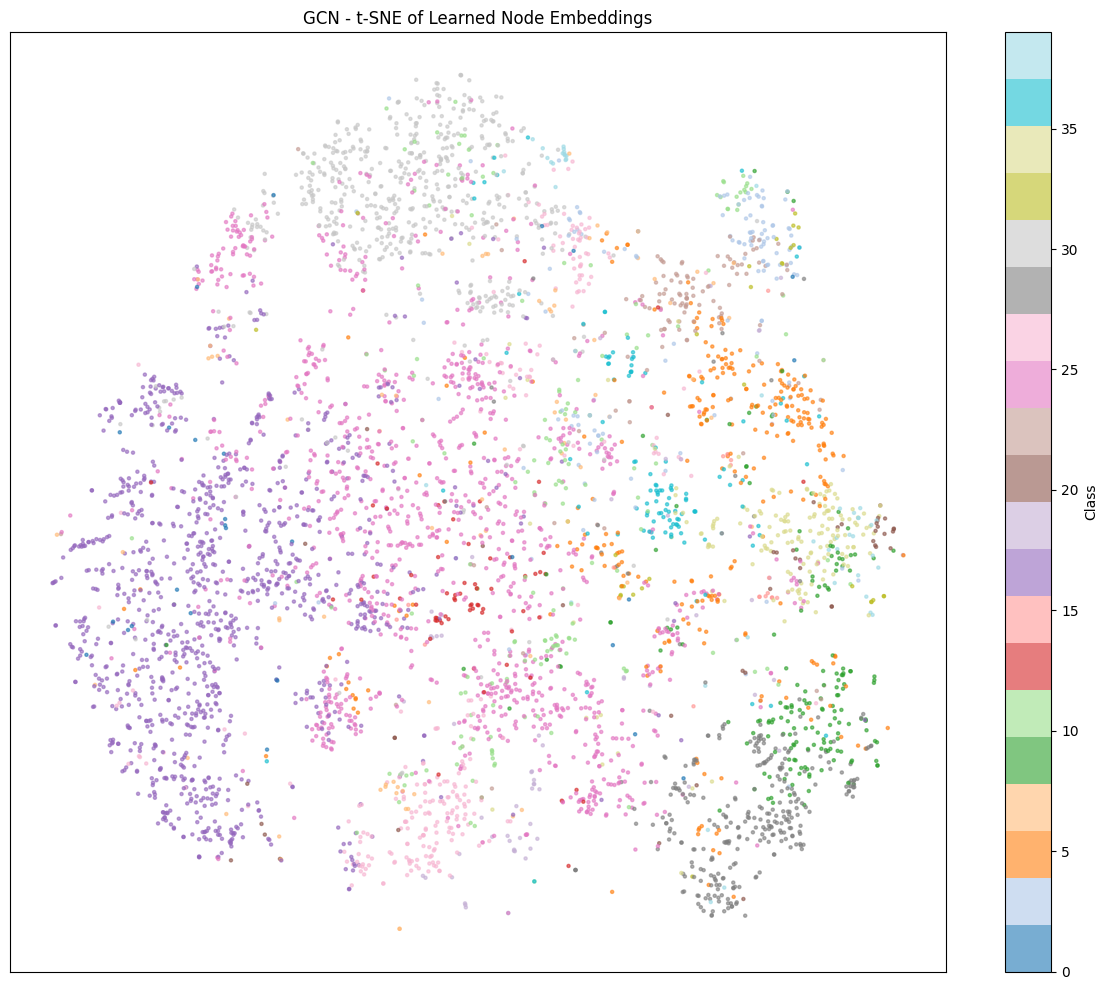

In [10]:
from sklearn.manifold import TSNE
import os

if os.path.exists('/kaggle/working/best_gcn.pt'):
    model.load_state_dict(torch.load('/kaggle/working/best_gcn.pt', map_location=device))
elif os.path.exists('best_gcn.pt'):
    model.load_state_dict(torch.load('best_gcn.pt', map_location=device))

@torch.no_grad()
def get_embeddings(model):
    model.eval()
    x = data.x
    for i, conv in enumerate(model.convs[:-1]):
        x = conv(x, data.edge_index)
        x = model.bns[i](x)
        x = F.relu(x)

    return x.detach().cpu()

all_embeds = get_embeddings(model)
test_embeds = all_embeds[test_idx.cpu()]
test_labels_for_tsne = data.y[test_idx].squeeze().detach().cpu()

n_samples = min(5000, len(test_embeds))
rng = np.random.default_rng(42)
indices = rng.choice(len(test_embeds), n_samples, replace=False)

embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels_for_tsne[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    embeds_2d[:, 0], embeds_2d[:, 1],
    c=labels_sub,
    cmap='tab20',
    s=5,
    alpha=0.6
)
ax.set_title('GCN - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()
